# HitBite — portfolio analytics

**Testnet demonstration on Base Sepolia. Simulated portfolio and attestation. Not an offer of securities.**

This notebook is the risk write-up for `hbTRS`, the whitelisted token that represents a *simulated*
custodied book of Türkiye USD sovereign bonds. It answers six questions a treasury desk or a vault
curator asks before they hold an instrument like this:

1. **When does cash actually arrive?** — the coupon and redemption calendar.
2. **What is the book worth, and how hard does it move?** — yield to maturity, modified duration and
   convexity, per bond and for the portfolio.
3. **How much NAV is at risk in a rate move?** — a parallel yield-shift table at ±50/100/200 bp.
4. **What happens when Türkiye's credit spread widens?** — a deliberately simple CDS mapping, with the
   assumption that drives it stated on the chart rather than buried in a config file.
5. **What does the fee schedule cost a holder?** — fee drag at 10M / 50M / 100M of AUM.
6. **What does a holder actually receive, next to the obvious alternative?** — distribution yield
   against an illustrative tokenized T-bill reference.

## Ground rules for this notebook

**Nothing here is re-derived.** Every number comes out of `nav_engine` — the same package that writes
`web/public/data/nav.json`, pushes the NAV integer on chain and signs the attestation. A notebook that
re-implemented accrual or the yield solver would drift from the published figures within a week, and the
first person to notice would be a reviewer holding two different numbers for the same fund. So the
notebook imports the engine, and the second cell below *asserts* that what it computed reproduces, field
for field, the documents the site serves.

**Nothing here depends on the wall clock.** The valuation date is read from the published `nav.json`, the
`generated_at` stamp with it. Two runs of this notebook produce identical output, which is what makes the
committed `.ipynb`, the exported HTML and the figures reviewable in a diff.

**Everything here is simulated.** The book holds three illustrative bonds whose coupons and maturities
were chosen to sit on the Türkiye USD curve as observed on 31 August 2026 (roughly 6.0% at 2029 to 7.8%
at 2047, 5-year CDS near 217 bp). The ISINs are `TBD`, the prices are made up, and the cash is test USDC.
Every chart says so.

In [1]:
from __future__ import annotations

import json
import sys
from dataclasses import dataclass
from datetime import date, timedelta
from decimal import Decimal
from pathlib import Path


def find_repo_root(start: Path | None = None) -> Path:
    # nbconvert runs the kernel in the notebook's own directory, but a contributor may open this
    # from anywhere, so locate the checkout by its landmarks instead of assuming a cwd.
    here = (start or Path.cwd()).resolve()
    for candidate in (here, *here.parents):
        if (candidate / "engine" / "nav_engine" / "__init__.py").is_file() and (
            candidate / "PLAN.md"
        ).is_file():
            return candidate
    raise RuntimeError(f"cannot locate the repository root from {here}")


ROOT = find_repo_root()
DATA_DIR = ROOT / "engine" / "data"
PUBLISHED_DIR = ROOT / "web" / "public" / "data"
FIG_DIR = ROOT / "docs" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

# `make notebook` runs this inside the engine's uv environment, where nav_engine is installed.
# Opening the notebook in a plain Jupyter that merely has the dependencies should still work.
if str(ROOT / "engine") not in sys.path:
    sys.path.insert(0, str(ROOT / "engine"))

import pandas as pd  # noqa: E402

from nav_engine import __version__ as engine_version  # noqa: E402
from nav_engine.bonds import coupon_schedule  # noqa: E402
from nav_engine.chain import ChainSnapshot  # noqa: E402
from nav_engine.distributions import load_distributions  # noqa: E402
from nav_engine.fees import daily_fee_accrual, daily_fee_rate  # noqa: E402
from nav_engine.money import fmt_unit, fmt_usd  # noqa: E402
from nav_engine.nav import compute_nav_path, distribution_yield  # noqa: E402
from nav_engine.outputs import build_documents  # noqa: E402
from nav_engine.pipeline import load_config  # noqa: E402
from nav_engine.portfolio import load_portfolio, load_prices  # noqa: E402
from nav_engine.scenarios import run_scenarios, shock  # noqa: E402

# ---------------------------------------------------------------- the as-of date, and where it comes from
# Not `date.today()`. The valuation date and the output stamp are taken from the document the site
# already serves, so this notebook can only ever describe a state that has been published. If that
# file is missing (a fresh checkout that has not run the engine yet) the pinned pair below is used.
PINNED_AS_OF = date(2026, 9, 14)
PINNED_GENERATED_AT = "2026-09-14T06:00:00Z"

nav_published_path = PUBLISHED_DIR / "nav.json"
if nav_published_path.is_file():
    _published_nav = json.loads(nav_published_path.read_text())
    AS_OF = date.fromisoformat(_published_nav["as_of"])
    GENERATED_AT = _published_nav["generated_at"]
else:
    AS_OF, GENERATED_AT = PINNED_AS_OF, PINNED_GENERATED_AT

# ---------------------------------------------------------------- run the engine
portfolio = load_portfolio(DATA_DIR / "portfolio.json")
prices = load_prices(DATA_DIR / "prices.csv")
config = load_config(DATA_DIR / "config.yaml")
distributions = load_distributions(DATA_DIR / "distributions.csv", missing_ok=True)

path = compute_nav_path(portfolio, prices, config, distributions, AS_OF)
day = path.last  # the as-of day: positions, cash, fees, NAV and weighted risk
dist_yield = distribution_yield(path, config.distribution_yield.trailing_months)
scenarios = run_scenarios(path, config.scenarios)

# No RPC from a notebook: the reference-book NAV does not depend on the chain, and reaching for a
# network would make the run non-reproducible. This is the same snapshot `nav-engine compute
# --no-chain` produces.
NO_CHAIN = ChainSnapshot(
    chain_id=None,
    token_address=None,
    total_supply_wei=None,
    onchain_nav_usdc_6dec=None,
    supply_source="none",
    warning=None,
)
documents = build_documents(
    path, dist_yield, scenarios, NO_CHAIN, config, portfolio, GENERATED_AT, []
)

# Bonds are read in maturity order everywhere in this notebook, because the colour ramp encodes it.
positions = sorted(day.positions, key=lambda v: v.bond.maturity)
FUND_FEE_PCT = config.fund.management_fee_pct_pa + config.fund.fund_expenses_pct_pa

pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 200)


def usd(value: Decimal) -> str:
    # The engine rounds HALF_UP at output; format from that string so a table can never show a
    # cent the published document does not.
    return f"{Decimal(fmt_usd(value)):,.2f}"


def unit(value: Decimal) -> str:
    return fmt_unit(value)


def pct(value: float, places: int = 2) -> str:
    return f"{value:.{places}f}%"

print(f"nav-engine {engine_version}")
print(f"as of        {AS_OF}   (inception {path.inception_date}, {(AS_OF - path.inception_date).days} days)")
print(f"generated at {GENERATED_AT}")
print(f"NAV total    {fmt_usd(day.nav_total)} USD   unit NAV {fmt_unit(day.nav_per_unit)}   ({day.nav_usdc_6dec} in USDC 6-dec integer units)")
print(f"book         {len(positions)} bonds, {fmt_usd(day.sum_market_value)} market value + {fmt_usd(day.cash)} cash - {fmt_usd(day.fees_payable)} fees payable")
print(f"risk         YTM {day.weighted_ytm_pct:.4f}%  modified duration {day.weighted_modified_duration:.4f} yrs  convexity {day.weighted_convexity:.4f}")

nav-engine 0.1.0
as of        2026-09-14   (inception 2026-09-08, 6 days)
generated at 2026-09-14T06:00:00Z
NAV total    1016860.71 USD   unit NAV 1.003061   (1003061 in USDC 6-dec integer units)
book         3 bonds, 1004535.67 market value + 12500.00 cash - 174.96 fees payable
risk         YTM 6.4210%  modified duration 4.5874 yrs  convexity 30.8827


## The tie-out

The engine is the source of truth, so the first thing this notebook does is prove it is looking at the
same state the site is. It rebuilds `nav.json` and `scenarios.json` from `engine/data/` and compares them
field by field with the documents committed under `web/public/data/`.

Two things are excluded, both for the same reason: they describe the chain rather than the reference
book. The `chain` block records whether an RPC was reachable — this notebook never opens a socket, so
it always reports "not configured", and its warning quotes a machine-local cache path. The reported-AUM
fields are unit NAV × `totalSupply`, which is the same chain read by another name. Nothing analysed
below lives in either.

Everything else is required to agree exactly. If the engine, the reference book and the published
documents ever move apart, the assertion at the end of this cell stops the notebook instead of quietly
publishing a second set of numbers.

In [2]:
def published(name: str) -> dict:
    return json.loads((PUBLISHED_DIR / f"{name}.json").read_text())


# Two blocks are excluded from the comparison, both for the same reason: they describe the chain,
# not the reference book. This notebook runs without an RPC, so `chain` is the "not configured"
# snapshot (and its warning quotes a machine-local cache path), and the reported-AUM figures, which
# are unit NAV x totalSupply, are null here whether or not the published run had a node to read.
# Nothing analysed in this notebook lives in either.
CHAIN_DERIVED_NAV_FIELDS = ("reported_aum_usd", "reported_aum_usdc_6dec")


def reference_book_view(document: dict) -> dict:
    view = {key: value for key, value in document.items() if key != "chain"}
    view["nav"] = {k: v for k, v in view["nav"].items() if k not in CHAIN_DERIVED_NAV_FIELDS}
    return view


nav_doc, scen_doc = documents.nav.model_dump(mode="json"), documents.scenarios.model_dump(mode="json")
nav_pub, scen_pub = published("nav"), published("scenarios")

spot_checks = [
    ("nav.json", "nav.per_token_usd", nav_doc["nav"]["per_token_usd"], nav_pub["nav"]["per_token_usd"]),
    ("nav.json", "nav.usdc_6dec", nav_doc["nav"]["usdc_6dec"], nav_pub["nav"]["usdc_6dec"]),
    ("nav.json", "nav.total_usd", nav_doc["nav"]["total_usd"], nav_pub["nav"]["total_usd"]),
    ("nav.json", "portfolio.sum_market_value_usd", nav_doc["portfolio"]["sum_market_value_usd"], nav_pub["portfolio"]["sum_market_value_usd"]),
    ("nav.json", "portfolio.fees_payable_usd", nav_doc["portfolio"]["fees_payable_usd"], nav_pub["portfolio"]["fees_payable_usd"]),
    ("nav.json", "portfolio.weighted_ytm_pct", nav_doc["portfolio"]["weighted_ytm_pct"], nav_pub["portfolio"]["weighted_ytm_pct"]),
    ("nav.json", "portfolio.modified_duration", nav_doc["portfolio"]["modified_duration"], nav_pub["portfolio"]["modified_duration"]),
    ("nav.json", "portfolio.convexity", nav_doc["portfolio"]["convexity"], nav_pub["portfolio"]["convexity"]),
    ("nav.json", "distribution_yield.window_days", nav_doc["distribution_yield"]["window_days"], nav_pub["distribution_yield"]["window_days"]),
    ("scenarios.json", "parallel[+200 bp].delta_usd", scen_doc["parallel"][-1]["delta_usd"], scen_pub["parallel"][-1]["delta_usd"]),
    ("scenarios.json", "parallel[+200 bp].nav_per_token_usd", scen_doc["parallel"][-1]["nav_per_token_usd"], scen_pub["parallel"][-1]["nav_per_token_usd"]),
    ("scenarios.json", "cds[+200 bp].delta_pct", scen_doc["cds"][-1]["delta_pct"], scen_pub["cds"][-1]["delta_pct"]),
]
tie_out = pd.DataFrame(
    [
        {
            "document": document,
            "field": field,
            "this notebook": computed,
            "published": served,
            "agrees": "yes" if computed == served else "NO",
        }
        for document, field, computed, served in spot_checks
    ]
)

whole_document = {
    "nav.json (every field except the chain block and the AUM derived from it)": reference_book_view(nav_doc) == reference_book_view(nav_pub),
    "scenarios.json (every field)": scen_doc == scen_pub,
}
for label, agrees in whole_document.items():
    print(f"{'MATCH  ' if agrees else 'DIFFERS'}  {label}")

assert all(whole_document.values()), (
    "this notebook and web/public/data disagree. Re-run `nav-engine compute` (or `make nav`) so the "
    "published documents match the reference book, then re-run the notebook."
)
tie_out.set_index(["document", "field"])

MATCH    nav.json (every field except the chain block and the AUM derived from it)
MATCH    scenarios.json (every field)


this notebook   published agrees
document       field                                                               
nav.json       nav.per_token_usd                        1.003061    1.003061    yes
               nav.usdc_6dec                             1003061     1003061    yes
               nav.total_usd                          1016860.71  1016860.71    yes
               portfolio.sum_market_value_usd         1004535.67  1004535.67    yes
               portfolio.fees_payable_usd                 174.96      174.96    yes
               portfolio.weighted_ytm_pct               6.421046    6.421046    yes
               portfolio.modified_duration              4.587369    4.587369    yes
               portfolio.convexity                     30.882722   30.882722    yes
               distribution_yield.window_days                  7           7    yes
scenarios.json parallel[+200 bp].delta_usd             -86281.15   -86281.15    yes
               parallel[+200 bp].nav_per_token_usd      0.917951    0.917951    yes
               cds[+200 bp].delta_pct                  -8.485051   -8.485051    yes

## The book

Three bonds and a cash balance. Face value is 1,000,000 USD spread 40/40/20 across a 2029, a 2034 and a
2036 maturity, plus 12,500 USD of cash — a barbell-ish ladder short enough to redeem into, long enough to
carry the curve. Positions are valued at the last clean price carried forward, plus accrued interest on
30/360 US, which is the convention these bonds actually trade on.

`market_value = face × (clean + accrued/face × 100) / 100`, and NAV total is the sum of those market
values plus cash minus the fees accrued and not yet paid. Unit NAV is that total divided by the reference
units fixed at inception, so it starts at exactly 1.000000 and every later move is the book's own P&L.

In [3]:
holdings = pd.DataFrame(
    [
        {
            "bond": p.name,
            "maturity": p.maturity.isoformat(),
            "coupon %": f"{float(p.coupon_pct):.2f}",
            "face USD": f"{p.face_usd:,.0f}",
            "clean price": f"{p.clean_price:.4f}",
            "accrued USD": usd(p.accrued_usd),
            "dirty price": f"{p.dirty_price:.6f}",
            "market value USD": usd(p.market_value_usd),
            "weight %": f"{p.weight_pct:.2f}",
        }
        for p in sorted(documents.holdings.positions, key=lambda p: p.maturity)
    ]
)
print(
    f"cash {usd(day.cash)}   fees payable {usd(day.fees_payable)}   "
    f"NAV total {usd(day.nav_total)}   unit NAV {unit(day.nav_per_unit)}"
)
print("Simulated reference book (testnet); ISINs are TBD and every price is illustrative.")
holdings.set_index("bond")

cash 12,500.00   fees payable 174.96   NAV total 1,016,860.71   unit NAV 1.003061
Simulated reference book (testnet); ISINs are TBD and every price is illustrative.


,maturity,coupon %,face USD,clean price,accrued USD,dirty price,market value USD,weight %
bond,,,,,,,,
TURKEY USD 6.00% 2029 (illustrative),2029-03-01,6.00,"400,000",100.1000,866.67,100.316667,"401,266.67",39.95
TURKEY USD 6.65% 2034 (illustrative),2034-03-01,6.65,"400,000",100.2500,960.56,100.490139,"401,960.56",40.01
TURKEY USD 7.04% 2036 (illustrative),2036-03-01,7.04,"200,000",100.4000,508.44,100.654222,"201,308.44",20.04


## Chart theme

The figures below are exported for the repository README, so they are drawn in the web app's own chart
language rather than matplotlib's: the design tokens from `web/app/globals.css`, the ordinal blue ramp
from `web/components/charts/chart-theme.css` (already validated for colour-vision deficiency and for
contrast against both surfaces), bars capped at 24 px with a 4 px rounded data-end, a 2 px surface gap
between touching marks, hairline horizontal gridlines and axis text in the muted ink token. Colour never
carries a value on its own — every figure ships the table that produced it.

Two files come out of every figure, `-light.svg` and `-dark.svg`, each drawn on its own opaque surface,
because a README is read on both a white and a near-black page and a transparent figure is legible on
exactly one of them.

The one deliberate departure: the app sets IBM Plex Sans, and these figures use DejaVu Sans, the face
that ships inside matplotlib. A system font would render differently on a contributor's machine and in
CI, and a figure that changes shape depending on who ran it is not a reproducible artifact.

In [4]:
import logging
from html import escape

import matplotlib as mpl

# The first matplotlib import on a machine logs "building the font cache" to stderr. That line is
# not an output of this analysis, and a committed notebook whose cells differ depending on whether
# the runner had a warm cache is not reproducible.
logging.getLogger("matplotlib").setLevel(logging.ERROR)

mpl.use("Agg")  # no interactive backend, no auto-display: every figure is written, then shown from disk

import matplotlib.pyplot as plt  # noqa: E402
from IPython.display import SVG, display  # noqa: E402
from matplotlib.lines import Line2D  # noqa: E402
from matplotlib.patches import PathPatch, Patch  # noqa: E402
from matplotlib.path import Path as MplPath  # noqa: E402
from matplotlib.ticker import FuncFormatter  # noqa: E402
from matplotlib.transforms import IdentityTransform  # noqa: E402


@dataclass(frozen=True)
class Theme:
    # Every value is a design token copied from web/app/globals.css, or a step of the validated
    # ordinal ramp in web/components/charts/chart-theme.css. Nothing here was eyeballed.
    mode: str
    surface: str  # --surface: the card the chart sits on, and the chart's own background
    ink: str  # --ink: titles and direct labels
    muted: str  # --muted: axis text, notes, legend text
    grid: str  # --border: hairline gridlines and the x-axis rule
    axis: str  # --border-strong: reference lines
    accent: str  # --accent: the single-series colour
    positive: str  # diverging pole "NAV up" — the accent, because a gain is the ordinary state
    negative: str  # diverging pole "NAV down" — the danger token; here the sign genuinely is the status
    ramp: tuple[str, str, str]  # rampScale(3): bonds in maturity order, least prominent first
    neutral: str  # --hb-viz-neutral: "not a bond" (principal, cash, an external reference)


# rampScale(3) returns ramp steps 1/3/5 of the five-step ordinal ramp, in both modes.
LIGHT = Theme(
    mode="light",
    surface="#ffffff",
    ink="#12141a",
    muted="#55606f",
    grid="#e4e4e0",
    axis="#878c85",
    accent="#2e6bff",
    positive="#2e6bff",
    negative="#b32318",
    ramp=("#8cb0f9", "#447af5", "#0a42d5"),
    neutral="#8a93a0",
)
DARK = Theme(
    mode="dark",
    surface="#14171d",
    ink="#e9ebef",
    muted="#99a1b0",
    grid="#242932",
    axis="#5f6673",
    accent="#5b8cff",
    positive="#5b8cff",
    negative="#f4776b",
    ramp=("#053bcc", "#3a72f5", "#83a9f9"),
    neutral="#8a93a0",
)
THEMES = (LIGHT, DARK)

FIG_DPI = 100
BAR_MAX_PX = 24.0  # marks spec: a bar is never thicker than 24 px — the slot's leftover is air
BAR_RADIUS_PX = 4.0  # rounded data-end, square where it meets the baseline
GAP_PX = 2.0  # the surface gap: what separates touching marks, instead of a stroke around them
KAPPA = 0.5523  # circular-arc control-point ratio for a cubic Bezier corner

SIM_NOTE = (
    "Simulated reference book on a public testnet. Coupons, maturities and prices are illustrative "
    "placeholders, not real securities."
)

mpl.rcParams.update(
    {
        # DejaVu Sans ships inside matplotlib, so the text metrics are identical on every machine.
        "font.family": "DejaVu Sans",
        "font.size": 8.5,
        "figure.dpi": FIG_DPI,
        "savefig.dpi": FIG_DPI,
        "svg.fonttype": "path",  # embed outlines: the figure cannot depend on the reader's fonts
        "path.simplify": False,  # deterministic vertex output
        "axes.unicode_minus": False,
    }
)


def _rounded_rect(x0: float, y0: float, x1: float, y1: float, r: float, side: str) -> MplPath:
    # A rectangle in *display pixels* with only the two corners on `side` rounded. Matplotlib has no
    # per-corner radius, and rounding in data units would give a different radius per axis scale.
    r = max(0.0, min(r, (x1 - x0) / 2.0, (y1 - y0) / 2.0))
    if r == 0.0 or side == "none":
        return MplPath(
            [(x0, y0), (x1, y0), (x1, y1), (x0, y1), (x0, y0)],
            [MplPath.MOVETO] + [MplPath.LINETO] * 3 + [MplPath.CLOSEPOLY],
        )
    k = KAPPA * r
    verts: list[tuple[float, float]] = []
    codes: list[int] = []

    def move(point: tuple[float, float]) -> None:
        verts.append(point)
        codes.append(MplPath.MOVETO)

    def line(point: tuple[float, float]) -> None:
        verts.append(point)
        codes.append(MplPath.LINETO)

    def arc(c1: tuple[float, float], c2: tuple[float, float], end: tuple[float, float]) -> None:
        verts.extend([c1, c2, end])
        codes.extend([MplPath.CURVE4] * 3)

    if side == "top":
        move((x0, y0))
        line((x0, y1 - r))
        arc((x0, y1 - r + k), (x0 + r - k, y1), (x0 + r, y1))
        line((x1 - r, y1))
        arc((x1 - r + k, y1), (x1, y1 - r + k), (x1, y1 - r))
        line((x1, y0))
    elif side == "bottom":
        move((x0, y1))
        line((x0, y0 + r))
        arc((x0, y0 + r - k), (x0 + r - k, y0), (x0 + r, y0))
        line((x1 - r, y0))
        arc((x1 - r + k, y0), (x1, y0 + r - k), (x1, y0 + r))
        line((x1, y1))
    elif side == "right":
        move((x0, y0))
        line((x1 - r, y0))
        arc((x1 - r + k, y0), (x1, y0 + r - k), (x1, y0 + r))
        line((x1, y1 - r))
        arc((x1, y1 - r + k), (x1 - r + k, y1), (x1 - r, y1))
        line((x0, y1))
    else:  # "left"
        move((x1, y0))
        line((x0 + r, y0))
        arc((x0 + r - k, y0), (x0, y0 + r - k), (x0, y0 + r))
        line((x0, y1 - r))
        arc((x0, y1 - r + k), (x0 + r - k, y1), (x0 + r, y1))
        line((x1, y1))
    verts.append(verts[0])
    codes.append(MplPath.CLOSEPOLY)
    return MplPath(verts, codes)


def _add_px_patch(ax, path: MplPath, color: str, zorder: float = 3.0) -> None:
    patch = PathPatch(path, facecolor=color, edgecolor="none", linewidth=0, zorder=zorder)
    patch.set_transform(IdentityTransform())  # the path is already in display pixels
    patch.set_clip_on(False)
    ax.add_artist(patch)  # add_artist, not add_patch: display-space vertices must not touch dataLim


def bar_width_px(ax, band_count: int, share: float = 0.7) -> float:
    # The app gives a bar 70% of its band and then caps it at 24 px.
    x0, x1 = ax.get_xlim()
    px_per_band = abs(ax.transData.transform((x1, 0))[0] - ax.transData.transform((x0, 0))[0]) / max(
        band_count, 1
    )
    return min(BAR_MAX_PX, px_per_band * share)


def column(ax, x, y0, y1, color, *, width_px, offset_px=0.0, round_end=True, gap_top=0.0, gap_bottom=0.0, zorder=3.0):
    # One vertical bar, sized in pixels so the 24 px cap, the 4 px radius and the 2 px gap are
    # exactly that on the exported image whatever the data range is.
    cx, py0 = ax.transData.transform((x, y0))
    py1 = ax.transData.transform((x, y1))[1]
    cx += offset_px  # grouped bars are positioned in pixels, so the 2 px surface gap is exact
    lo, hi = (py0, py1) if py1 >= py0 else (py1, py0)
    lo, hi = lo + gap_bottom, hi - gap_top
    if hi - lo <= 0.2:
        return
    side = ("top" if py1 >= py0 else "bottom") if round_end else "none"
    _add_px_patch(ax, _rounded_rect(cx - width_px / 2, lo, cx + width_px / 2, hi, BAR_RADIUS_PX, side), color, zorder)


def hbar(ax, y, x0, x1, color, *, height_px, round_end=True, zorder=3.0):
    px0, cy = ax.transData.transform((x0, y))
    px1 = ax.transData.transform((x1, y))[0]
    lo, hi = (px0, px1) if px1 >= px0 else (px1, px0)
    if hi - lo <= 0.2:
        return
    side = ("right" if px1 >= px0 else "left") if round_end else "none"
    _add_px_patch(ax, _rounded_rect(lo, cy - height_px / 2, hi, cy + height_px / 2, BAR_RADIUS_PX, side), color, zorder)


def stacked_column(ax, x, segments, *, width_px, zorder=3.0):
    # segments: [(value, colour)] bottom-to-top. Neighbours are separated by the 2 px surface gap,
    # and only the top of the whole stack carries the rounded data-end.
    bottom = 0.0
    for index, (value, color) in enumerate(segments):
        top = bottom + value
        column(
            ax,
            x,
            bottom,
            top,
            color,
            width_px=width_px,
            round_end=index == len(segments) - 1,
            gap_top=0.0 if index == len(segments) - 1 else GAP_PX,
            zorder=zorder,
        )
        bottom = top


def style_axes(ax, theme: Theme, *, x_rule: bool = True, grid_axis: str = "y") -> None:
    # The app's chart chrome: no box, one hairline rule under the category axis, solid recessive
    # gridlines on the value axis only, no tick marks, axis text in the muted token.
    ax.set_facecolor(theme.surface)
    for side in ("top", "right", "left"):
        ax.spines[side].set_visible(False)
    ax.spines["bottom"].set_visible(x_rule)
    ax.spines["bottom"].set_color(theme.grid)
    ax.spines["bottom"].set_linewidth(1.0)
    ax.tick_params(length=0, colors=theme.muted, labelsize=8.5, pad=5)
    if grid_axis != "none":
        ax.grid(visible=True, axis=grid_axis, color=theme.grid, linewidth=1.0, linestyle="-")
    ax.set_axisbelow(True)


def axis_title(ax, theme: Theme, text: str) -> None:
    ax.set_title(text, color=theme.ink, fontsize=9.5, loc="left", pad=8)


def legend(ax, theme: Theme, handles, *, loc="upper left", bbox=None, ncol=1):
    # Identity is never colour alone: a legend is present for every figure with two or more series.
    box = ax.legend(
        handles=handles,
        loc=loc,
        bbox_to_anchor=bbox,
        frameon=False,
        fontsize=8.5,
        labelcolor=theme.muted,
        handlelength=0.9,
        handleheight=0.9,
        handletextpad=0.6,
        borderpad=0,
        labelspacing=0.5,
        columnspacing=1.4,
        ncol=ncol,
    )
    return box


def swatch(color: str, label: str) -> Patch:
    return Patch(facecolor=color, edgecolor="none", label=label)


def money_axis(ax, theme: Theme, *, unit_divisor: float = 1.0, suffix: str = "") -> None:
    ax.yaxis.set_major_formatter(
        FuncFormatter(lambda v, _pos: "0" if v == 0 else f"{v / unit_divisor:,.0f}{suffix}")
    )


def _wrap(fig, text: str, max_px: float, fontsize: float) -> list[str]:
    # Wrap on *measured* width, not on a character count: an assumption line that runs off the
    # canvas is the commonest way a standalone figure loses the caveat it exists to carry.
    renderer = fig.canvas.get_renderer()
    probe = fig.text(0.0, 0.0, "", fontsize=fontsize)
    lines: list[str] = []
    current = ""
    for word in text.split():
        trial = f"{current} {word}".strip()
        probe.set_text(trial)
        if current and probe.get_window_extent(renderer).width > max_px:
            lines.append(current)
            current = word
        else:
            current = trial
    probe.remove()
    lines.append(current)
    return lines


def frame(fig, theme: Theme, *, title: str, subtitle: str, notes: list[str]) -> None:
    # The standalone equivalent of the app's chart card: a title, the assumption line under it, and
    # the provenance footer that every figure in this repository carries.
    width_px, height_px = (dimension * FIG_DPI for dimension in fig.get_size_inches())
    inner = width_px - 26
    fig.text(0.013, 0.975, title, ha="left", va="top", color=theme.ink, fontsize=11.5, fontweight="bold")
    for index, line in enumerate(_wrap(fig, subtitle, inner, 8.5)):
        fig.text(
            0.013, (height_px - 32 - index * 12) / height_px, line,
            ha="left", va="top", color=theme.muted, fontsize=8.5,
        )
    lines = [line for note in notes for line in _wrap(fig, note, inner, 7.5)]
    for index, line in enumerate(reversed(lines)):
        fig.text(
            0.013, (13 + index * 11) / height_px, line,
            ha="left", va="bottom", color=theme.muted, fontsize=7.5,
        )


def _name_the_figure(target: Path, title: str, subtitle: str) -> None:
    # Give the standalone file an accessible name. An SVG served from a README is an image with no
    # surrounding prose, so the title and the assumption line have to travel inside it.
    svg = target.read_text()
    head = svg.index(">", svg.index("<svg ")) + 1
    target.write_text(
        svg[:head]
        + f"\n <title>{escape(title, quote=False)}</title>"
        + f"\n <desc>{escape(subtitle, quote=False)}</desc>"
        + svg[head:]
    )


def render(name: str, draw, *, size, title: str, subtitle: str, notes: list[str], show: str = "light") -> None:
    # Draw the same figure once per mode and write both. A README is read on a white page and on a
    # near-black one; a single transparent figure is legible on exactly one of them.
    #
    # Returns nothing on purpose: a returned Path would be echoed as the cell's result and would put
    # this machine's absolute directory into the committed notebook.
    written: dict[str, Path] = {}
    for theme in THEMES:
        # A per-figure salt keeps matplotlib's generated element ids stable across runs *and*
        # unique across figures — several of these SVGs are inlined into one HTML page, where two
        # identical clip-path ids would silently clip the wrong figure.
        mpl.rcParams["svg.hashsalt"] = f"hitbite-{name}-{theme.mode}"
        fig = plt.figure(figsize=size, dpi=FIG_DPI, facecolor=theme.surface)
        frame(fig, theme, title=title, subtitle=subtitle, notes=notes)
        draw(fig, theme)
        target = FIG_DIR / f"{name}-{theme.mode}.svg"
        fig.savefig(
            target,
            format="svg",
            dpi=FIG_DPI,
            facecolor=theme.surface,
            # No Date: the SVG backend would otherwise stamp the run time into the file and every
            # re-run would be a diff.
            metadata={"Date": None, "Creator": "HitBite notebooks/portfolio_analytics.ipynb"},
        )
        plt.close(fig)
        _name_the_figure(target, title, subtitle)
        written[theme.mode] = target
    FIGURES.append(name)
    display(SVG(filename=str(written[show])))


FIGURES: list[str] = []
print(f"figures will be written to {FIG_DIR.relative_to(ROOT)}/ (light and dark, SVG)")

figures will be written to docs/figures/ (light and dark, SVG)


## 1. The cash-flow calendar

A bond fund is a schedule of dated payments; everything else — NAV, duration, the redemption queue — is
a consequence of it. The calendar below is contractual, not forecast: `nav_engine.bonds.coupon_schedule`
generates each bond's dates backwards from maturity on a 30/360 US semi-annual clock, so these are the
days on which cash lands in the vault, and the days on which `distributeCoupon` has something to
distribute.

Two things are worth noticing. First, every bond in the simulated book pays on 1 March and 1 September,
so the fund's income arrives in two lumps a year rather than smoothly — a redemption queue that assumes
a steady drip of cash would be wrong about this fund. Second, the principal repayments dwarf the coupons:
400,000 USD comes back in 2029 against 64,680 USD of coupon income in a full year. That is the
reinvestment risk in this structure, and it is why the two panels below are drawn on separate scales
instead of stacked into one misleading column.

In [5]:
def short_name(valuation) -> str:
    return f"{float(valuation.bond.coupon_pct):.2f}% {valuation.bond.maturity.year}"


flows = []
for valuation in positions:
    bond = valuation.bond
    for pay_date in coupon_schedule(bond, day.date):  # engine schedule, not a re-derived one
        flows.append(
            {"date": pay_date, "bond": short_name(valuation), "kind": "Coupon", "amount": bond.coupon_per_period}
        )
        if pay_date == bond.maturity:
            flows.append(
                {"date": pay_date, "bond": short_name(valuation), "kind": "Principal", "amount": bond.face_usd}
            )
cash_flows_df = pd.DataFrame(flows).sort_values(["date", "bond"], ignore_index=True)

bond_labels = [short_name(v) for v in positions]
years = sorted({d.year for d in cash_flows_df["date"]})
coupons_by_year = pd.DataFrame(
    {
        label: [
            float(
                cash_flows_df[
                    (cash_flows_df["kind"] == "Coupon")
                    & (cash_flows_df["bond"] == label)
                    & (cash_flows_df["date"].map(lambda d: d.year) == year)
                ]["amount"].sum()
            )
            for year in years
        ]
        for label in bond_labels
    },
    index=years,
)
principal_by_year = pd.Series(
    [
        float(
            cash_flows_df[
                (cash_flows_df["kind"] == "Principal")
                & (cash_flows_df["date"].map(lambda d: d.year) == year)
            ]["amount"].sum()
        )
        for year in years
    ],
    index=years,
    name="Principal",
)

calendar = coupons_by_year.copy()
calendar["Coupon total"] = calendar.sum(axis=1)
calendar["Principal"] = principal_by_year
calendar["Year total"] = calendar["Coupon total"] + calendar["Principal"]
calendar.index.name = "year"

horizon = AS_OF + timedelta(days=365)
next_year = cash_flows_df[cash_flows_df["date"] <= horizon].copy()
print(f"Next 12 months ({AS_OF} to {horizon}): {len(next_year)} payments, {usd(Decimal(next_year['amount'].sum()))} USD")
print(f"First payment {next_year['date'].min()} — {(next_year['date'].min() - AS_OF).days} days after the valuation date.")
print(f"Total contractual cash still to come: {usd(Decimal(cash_flows_df['amount'].sum()))} USD on {len(cash_flows_df)} dates.")
calendar.map(lambda v: f"{v:,.0f}")

Next 12 months (2026-09-14 to 2027-09-14): 6 payments, 64,680.00 USD
First payment 2027-03-01 — 168 days after the valuation date.
Total contractual cash still to come: 1,393,260.00 USD on 42 dates.


,6.00% 2029,6.65% 2034,7.04% 2036,Coupon total,Principal,Year total
year,,,,,,
2027,"24,000","26,600","14,080","64,680",0,"64,680"
2028,"24,000","26,600","14,080","64,680",0,"64,680"
2029,"12,000","26,600","14,080","52,680","400,000","452,680"
2030,0,"26,600","14,080","40,680",0,"40,680"
2031,0,"26,600","14,080","40,680",0,"40,680"
2032,0,"26,600","14,080","40,680",0,"40,680"
2033,0,"26,600","14,080","40,680",0,"40,680"
2034,0,"13,300","14,080","27,380","400,000","427,380"
2035,0,0,"14,080","14,080",0,"14,080"


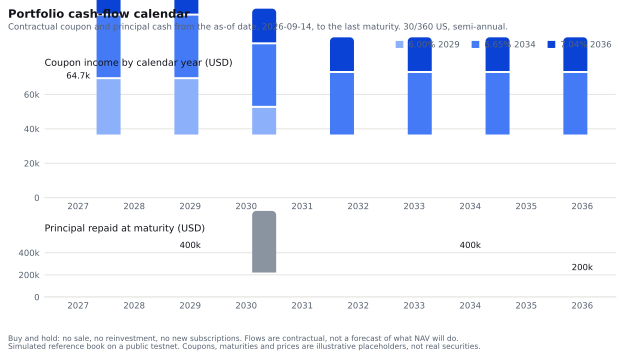

In [6]:
def draw_cashflow(fig, theme: Theme) -> None:
    grid = fig.add_gridspec(2, 1, height_ratios=[2.15, 1.0], left=0.072, right=0.995, top=0.795, bottom=0.175, hspace=0.46)
    ax_coupon, ax_principal = fig.add_subplot(grid[0]), fig.add_subplot(grid[1])
    x = list(range(len(years)))

    for ax, top in ((ax_coupon, 72_000.0), (ax_principal, 520_000.0)):
        ax.set_xlim(-0.6, len(years) - 0.4)
        ax.set_ylim(0, top)
        ax.set_xticks(x)
        ax.set_xticklabels([str(year) for year in years])
        style_axes(ax, theme)
        money_axis(ax, theme, unit_divisor=1000.0, suffix="k")
    ax_principal.set_yticks([0, 200_000, 400_000])

    width = bar_width_px(ax_coupon, len(years))
    for index, year in enumerate(years):
        stacked_column(
            ax_coupon,
            index,
            [(coupons_by_year.loc[year, label], theme.ramp[slot]) for slot, label in enumerate(bond_labels)],
            width_px=width,
        )
        if principal_by_year[year] > 0:
            column(ax_principal, index, 0, principal_by_year[year], theme.neutral, width_px=width)
            ax_principal.text(
                index,
                principal_by_year[year] + 24_000,
                f"{principal_by_year[year] / 1000:,.0f}k",
                ha="center", va="bottom", color=theme.ink, fontsize=8.5,
            )

    # Direct-label the first full coupon year only; the axis and the table carry the rest.
    first_total = float(coupons_by_year.loc[years[0]].sum())
    ax_coupon.text(0, first_total + 3_400, f"{first_total / 1000:,.1f}k", ha="center", va="bottom", color=theme.ink, fontsize=8.5)

    axis_title(ax_coupon, theme, "Coupon income by calendar year (USD)")
    axis_title(ax_principal, theme, "Principal repaid at maturity (USD)")
    legend(
        ax_coupon,
        theme,
        [swatch(theme.ramp[slot], label) for slot, label in enumerate(bond_labels)],
        loc="upper right",
        bbox=(1.0, 1.30),
        ncol=3,
    )


render(
    "cashflow-calendar",
    draw_cashflow,
    size=(8.6, 5.0),
    title="Portfolio cash-flow calendar",
    subtitle=f"Contractual coupon and principal cash from the as-of date, {AS_OF}, to the last maturity. 30/360 US, semi-annual.",
    notes=[
        "Buy and hold: no sale, no reinvestment, no new subscriptions. Flows are contractual, not a forecast of what NAV will do.",
        SIM_NOTE,
    ],
)

## 2. Yield, duration and convexity

Three numbers describe a bond's price behaviour, and the engine computes all three from the same dirty
price it used for NAV, so they cannot drift from the valuation.

**Yield to maturity** is the single discount rate that makes the remaining cash flows worth today's
dirty price — street convention, semi-annual compounding, a fractional first period on 30/360.
`nav_engine.bonds.solve_ytm` brackets the root and refines it with Newton safeguarded by bisection, so
it converges on any price the book can legitimately hold rather than wandering off on a bad input. It is
a *held-to-maturity* return, not a promise: it assumes every coupon is reinvested at the same yield and
that the issuer pays.

**Modified duration** is the first derivative: the percentage of market value lost for a 100 bp parallel
rise in yields. **Convexity** is the second derivative — the curvature that makes the loss on a rise
smaller than the gain on an equal fall. The 2036 line has 6.82 years of duration against the 2029's 2.26,
which is the whole reason the book is laddered: the short leg is the redemption buffer, the long leg is
the yield.

The portfolio figures are market-value weighted, which is what makes them additive: the weighted duration
below is exactly the duration that reprices the book in the next section.

In [7]:
risk = pd.DataFrame(
    [
        {
            "bond": short_name(v),
            "maturity": v.bond.maturity.isoformat(),
            "market value USD": usd(v.market_value),
            "weight %": f"{float(v.market_value / day.sum_market_value) * 100:.2f}",
            "YTM %": f"{v.ytm_pct:.4f}",
            "modified duration (yrs)": f"{v.modified_duration:.4f}",
            "convexity (yrs²)": f"{v.convexity:.4f}",
            # A restatement of duration in money: what one basis point of yield is worth on this line.
            "1 bp of yield (USD)": usd(v.market_value * Decimal(repr(v.modified_duration)) / Decimal(10_000)),
        }
        for v in positions
    ]
)
portfolio_row = {
    "bond": "Portfolio (market-value weighted)",
    "maturity": "—",
    "market value USD": usd(day.sum_market_value),
    "weight %": "100.00",
    "YTM %": f"{day.weighted_ytm_pct:.4f}",
    "modified duration (yrs)": f"{day.weighted_modified_duration:.4f}",
    "convexity (yrs²)": f"{day.weighted_convexity:.4f}",
    "1 bp of yield (USD)": usd(
        day.sum_market_value * Decimal(repr(day.weighted_modified_duration)) / Decimal(10_000)
    ),
}
risk = pd.concat([risk, pd.DataFrame([portfolio_row])], ignore_index=True)
print("Cash (12,500.00 USD) carries no duration, so the portfolio risk figures below are a share of the")
print("bond market value, not of NAV total. Every price is illustrative; the book is simulated (testnet).")
risk.set_index("bond")

Cash (12,500.00 USD) carries no duration, so the portfolio risk figures below are a share of the
bond market value, not of NAV total. Every price is illustrative; the book is simulated (testnet).


,maturity,market value USD,weight %,YTM %,modified duration (yrs),convexity (yrs²),1 bp of yield (USD)
bond,,,,,,,
6.00% 2029,2029-03-01,"401,266.67",39.95,5.9545,2.2554,6.3649,90.50
6.65% 2034,2034-03-01,"401,960.56",40.01,6.6064,5.7994,41.3294,233.11
7.04% 2036,2036-03-01,"201,308.44",20.04,6.9809,6.8155,58.8948,137.20
Portfolio (market-value weighted),—,"1,004,535.67",100.00,6.4210,4.5874,30.8827,460.82


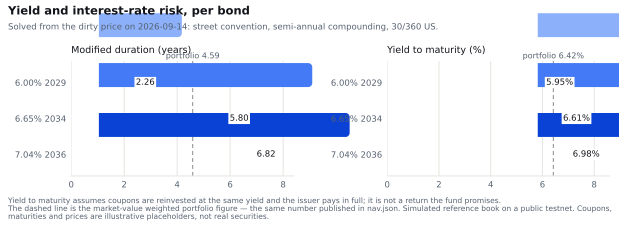

In [8]:
def draw_risk(fig, theme: Theme) -> None:
    grid = fig.add_gridspec(1, 2, left=0.115, right=0.985, top=0.735, bottom=0.235, wspace=0.42)
    panels = [
        (
            fig.add_subplot(grid[0]),
            "Modified duration (years)",
            [v.modified_duration for v in positions],
            day.weighted_modified_duration,
            8.4,
            "{:.2f}",
        ),
        (
            fig.add_subplot(grid[1]),
            "Yield to maturity (%)",
            [v.ytm_pct for v in positions],
            day.weighted_ytm_pct,
            8.6,
            "{:.2f}%",
        ),
    ]
    labels = [short_name(v) for v in positions]
    for ax, title, values, weighted, top, fmt in panels:
        ax.set_ylim(-0.6, len(values) - 0.4)
        ax.set_xlim(0, top)
        ax.invert_yaxis()  # shortest maturity at the top, the order the ramp encodes
        ax.set_yticks(range(len(values)))
        ax.set_yticklabels(labels)
        style_axes(ax, theme, grid_axis="x")
        height = min(BAR_MAX_PX, 0.7 * abs(ax.transData.transform((0, 0))[1] - ax.transData.transform((0, 1))[1]))
        for index, value in enumerate(values):
            hbar(ax, index, 0, value, theme.ramp[index], height_px=height)
            ax.text(
                value + top * 0.022, index, fmt.format(value),
                ha="left", va="center", color=theme.ink, fontsize=8.5, zorder=5,
                # The surface behind the label is the same spacer the marks spec uses on overlapping
                # marks: it keeps the value legible where it crosses the reference line.
                bbox=dict(facecolor=theme.surface, edgecolor="none", pad=1.4),
            )
        # The weighted portfolio figure as a reference line: dashed, so it reads as a threshold
        # rather than as another bar.
        ax.axvline(weighted, color=theme.axis, linewidth=1.0, linestyle=(0, (4, 3)), zorder=2)
        ax.text(
            weighted, -0.62, f"portfolio {fmt.format(weighted)}",
            ha="center", va="bottom", color=theme.muted, fontsize=8,
        )
        axis_title(ax, theme, title)


render(
    "risk-by-bond",
    draw_risk,
    size=(8.6, 3.2),
    title="Yield and interest-rate risk, per bond",
    subtitle=f"Solved from the dirty price on {AS_OF}: street convention, semi-annual compounding, 30/360 US.",
    notes=[
        "Yield to maturity assumes coupons are reinvested at the same yield and the issuer pays in full; it is not a return the fund promises.",
        "The dashed line is the market-value weighted portfolio figure — the same number published in nav.json. " + SIM_NOTE,
    ],
)

## 3. NAV sensitivity to a parallel yield shift

This is the number a collateral desk asks for first: if the whole USD curve moves, how much NAV is left?

The engine answers it by repricing, not by approximating. `nav_engine.scenarios.nav_after_shift` takes
each bond's own solved yield, adds the shift, discounts the remaining cash flows at the new yield and
rebuilds NAV total from the repriced market values. Cash and the accrued fee liability do not move, which
is the honest treatment: a rate shock repriced the bonds, it did not spend the cash.

The table also carries the textbook approximation, `ΔNAV ≈ market value × (−D·Δy + ½·C·Δy²)`, using the
market-value weighted duration and convexity from the previous section. It is there to be checked, not
to be used: at ±50 bp it is within 5 USD of the full repricing on a million-dollar book, and even at
±200 bp it is off by only about 3 bp of NAV. That agreement is the evidence that the weighted risk
figures published in `nav.json` actually describe this portfolio.

Note the asymmetry in the full repricing: −200 bp adds 98,721 USD while +200 bp costs 86,281 USD. That
gap *is* convexity, and it is the one part of the risk profile that works in the holder's favour.

In [9]:
def approx_delta_usd(shift_bp: float) -> Decimal:
    # Second-order approximation from the published weighted risk figures, for comparison only.
    delta_y = shift_bp / 10_000.0
    factor = -day.weighted_modified_duration * delta_y + 0.5 * day.weighted_convexity * delta_y**2
    return day.sum_market_value * Decimal(repr(factor))


sensitivity = pd.DataFrame(
    [
        {
            "shift (bp)": f"{int(s.shift_bp):+d}",
            "NAV total USD": usd(s.nav_total),
            "NAV per token USD": unit(s.nav_per_unit),
            "change USD": usd(s.delta_usd),
            "change %": f"{s.delta_pct:+.4f}",
            "duration+convexity %": f"{float(approx_delta_usd(s.shift_bp) / day.nav_total) * 100:+.4f}",
            "approximation error (bp of NAV)": f"{float((s.delta_usd - approx_delta_usd(s.shift_bp)) / day.nav_total) * 10_000:+.2f}",
        }
        for s in scenarios.parallel
    ]
)
base_row = pd.DataFrame(
    [
        {
            "shift (bp)": "0 (base)",
            "NAV total USD": usd(day.nav_total),
            "NAV per token USD": unit(day.nav_per_unit),
            "change USD": "0.00",
            "change %": "+0.0000",
            "duration+convexity %": "+0.0000",
            "approximation error (bp of NAV)": "+0.00",
        }
    ]
)
sensitivity = pd.concat(
    [sensitivity.iloc[:3], base_row, sensitivity.iloc[3:]], ignore_index=True
)
print(scenarios.assumptions)
sensitivity.set_index("shift (bp)")

Parallel shifts reprice every bond at its own yield to maturity plus the shift on the as-of date (street convention, semi-annual, 30/360), holding cash and fees payable unchanged. CDS shocks pass 1:1 into yields (beta = 1): a spread shock of s bp is treated as a parallel +s x beta bp yield shift. Real pass-through varies with tenor and basis; illustrative only. Simulated data (testnet).


,NAV total USD,NAV per token USD,change USD,change %,duration+convexity %,approximation error (bp of NAV)
shift (bp),,,,,,
-200,"1,115,581.72",1.100442,"98,721.01",+9.7084,+9.6737,+3.47
-100,"1,064,536.70",1.050090,"47,675.99",+4.6885,+4.6843,+0.42
-50,"1,040,294.69",1.026177,"23,433.99",+2.3045,+2.3040,+0.05
0 (base),"1,016,860.71",1.003061,0.00,+0.0000,+0.0000,+0.00
+50,"994,202.41",0.980710,"-22,658.30",-2.2283,-2.2277,-0.05
+100,"972,288.91",0.959094,"-44,571.79",-4.3833,-4.3792,-0.40
+200,"930,579.56",0.917951,"-86,281.15",-8.4851,-8.4534,-3.17


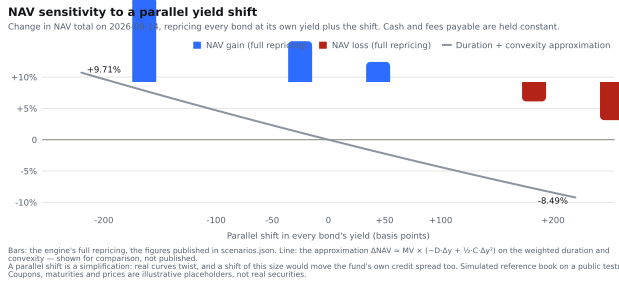

In [10]:
SHIFT_AXIS = [float(s) for s in range(-220, 221, 4)]


def draw_sensitivity(fig, theme: Theme) -> None:
    ax = fig.add_axes((0.068, 0.265, 0.925, 0.50))
    ax.set_xlim(-255, 255)
    ax.set_ylim(-11.5, 11.5)
    ax.set_xticks([-200, -100, -50, 0, 50, 100, 200])
    ax.set_xticklabels(["-200", "-100", "-50", "0", "+50", "+100", "+200"])
    ax.set_yticks([-10, -5, 0, 5, 10])
    style_axes(ax, theme, x_rule=False)
    ax.yaxis.set_major_formatter(FuncFormatter(lambda v, _pos: f"{v:+.0f}%" if v else "0"))
    ax.set_xlabel("Parallel shift in every bond's yield (basis points)", color=theme.muted, fontsize=8.5, labelpad=7)

    # The approximation, drawn as a continuous curve so the reader can see it *is* a curve.
    ax.plot(
        SHIFT_AXIS,
        [float(approx_delta_usd(s) / day.nav_total) * 100 for s in SHIFT_AXIS],
        color=theme.neutral, linewidth=2.0, solid_capstyle="round", zorder=4,
    )
    for s in scenarios.parallel:
        color = theme.positive if s.delta_pct > 0 else theme.negative
        column(ax, s.shift_bp, 0, s.delta_pct, color, width_px=BAR_MAX_PX)
    ax.axhline(0, color=theme.axis, linewidth=1.0, zorder=2)

    # Direct-label the extremes only: the axis, and the table below, carry the rest.
    for s in (scenarios.parallel[0], scenarios.parallel[-1]):
        above = s.delta_pct > 0
        ax.text(
            s.shift_bp, s.delta_pct + (0.7 if above else -0.7), f"{s.delta_pct:+.2f}%",
            ha="center", va="bottom" if above else "top", color=theme.ink, fontsize=8.5,
        )
    legend(
        ax, theme,
        [
            swatch(theme.positive, "NAV gain (full repricing)"),
            swatch(theme.negative, "NAV loss (full repricing)"),
            Line2D([], [], color=theme.neutral, linewidth=2.0, label="Duration + convexity approximation"),
        ],
        loc="upper right", bbox=(1.0, 1.21), ncol=3,
    )


render(
    "nav-sensitivity",
    draw_sensitivity,
    size=(8.6, 4.0),
    title="NAV sensitivity to a parallel yield shift",
    subtitle=f"Change in NAV total on {AS_OF}, repricing every bond at its own yield plus the shift. Cash and fees payable are held constant.",
    notes=[
        "Bars: the engine's full repricing, the figures published in scenarios.json. Line: the approximation \u0394NAV \u2248 MV \u00d7 (\u2212D\u00b7\u0394y + \u00bd\u00b7C\u00b7\u0394y\u00b2) on the weighted duration and convexity \u2014 shown for comparison, not published.",
        "A parallel shift is a simplification: real curves twist, and a shift of this size would move the fund's own credit spread too. " + SIM_NOTE,
    ],
)

## 4. A CDS shock, and the assumption that drives it

Türkiye's USD bonds move with Türkiye's credit, and the market's price for that credit is the 5-year CDS
spread — quoted near 217 bp on 31 August 2026, the level recorded in `engine/data/config.yaml` for
context.

Mapping a spread move into a NAV move requires an assumption, and the MVP makes the simplest one it can
state plainly: **a CDS spread shock of *s* basis points is treated as a parallel *s × β* basis-point
shift in every bond's yield, with β = 1.0.** That is a 1:1 pass-through. It is written into
`config.yaml` as `scenarios.cds.beta_to_yield`, repeated in the `assumptions` string of every
`scenarios.json`, and printed on the figure below, because an assumption a reader has to go and find is
an assumption they will not find.

It is also wrong in the way all simple models are wrong. Real pass-through is not 1:1 and not flat: the
bond-CDS basis moves, the spread curve is not parallel to the yield curve, and a 200 bp spread widening
usually arrives with a currency move and a liquidity squeeze rather than on its own. So the figure shows
what the answer would be at β = 0.5 and β = 0.75 as well — the spread between those bars is the value of
the assumption itself, and at 200 bp it is worth about 4.3% of NAV. Only the β = 1.0 column is published.

In production this is where a measured, tenor-by-tenor pass-through from the issuer's own curve replaces
the constant, and the model becomes a risk model rather than an illustration.

In [11]:
BETAS = (0.5, 0.75, 1.0)
published_beta = config.scenarios.cds.beta_to_yield
reference_cds_bp = config.scenarios.cds.reference_5y_cds_bp

cds_grid = {
    beta: [shock(day, float(s) * beta) for s in config.scenarios.cds.shocks_bp] for beta in BETAS
}
cds_table = pd.DataFrame(
    [
        {
            "CDS shock (bp)": f"+{int(base.shock_bp)}",
            "beta": f"{beta:.2f}",
            "implied yield shift (bp)": f"+{beta * base.shock_bp:g}",
            "NAV total USD": usd(cds_grid[beta][index].nav_total),
            "NAV per token USD": unit(cds_grid[beta][index].nav_per_unit),
            "change USD": usd(cds_grid[beta][index].delta_usd),
            "change %": f"{cds_grid[beta][index].delta_pct:+.4f}",
            "published": "scenarios.json" if beta == published_beta else "illustration only",
        }
        for index, base in enumerate(scenarios.cds)
        for beta in BETAS
    ]
)

print(f"Stated assumption: a CDS spread shock passes into yields with beta = {published_beta:.2f} (1:1 pass-through).")
print(f"Reference level recorded in config.yaml for context: 5-year CDS {reference_cds_bp:g} bp (31 Aug 2026).")
print("Simulated data (testnet). Pass-through is a modelling choice here, not a measured relationship.")
cds_table.set_index(["CDS shock (bp)", "beta"])

Stated assumption: a CDS spread shock passes into yields with beta = 1.00 (1:1 pass-through).
Reference level recorded in config.yaml for context: 5-year CDS 217 bp (31 Aug 2026).
Simulated data (testnet). Pass-through is a modelling choice here, not a measured relationship.


implied yield shift (bp) NAV total USD NAV per token USD  change USD change %          published
CDS shock (bp) beta                                                                                                 
+50            0.50                      +25  1,005,436.56          0.991792  -11,424.15  -1.1235  illustration only
               0.75                    +37.5    999,795.98          0.986228  -17,064.73  -1.6782  illustration only
               1.00                      +50    994,202.41          0.980710  -22,658.30  -2.2283     scenarios.json
+100           0.50                      +50    994,202.41          0.980710  -22,658.30  -2.2283  illustration only
               0.75                      +75    983,154.44          0.969812  -33,706.27  -3.3147  illustration only
               1.00                     +100    972,288.91          0.959094  -44,571.79  -4.3833     scenarios.json
+200           0.50                     +100    972,288.91          0.959094  -44,571.79  -4.3833  illustration only
               0.75                     +150    951,090.70          0.938183  -65,770.01  -6.4679  illustration only
               1.00                     +200    930,579.56          0.917951  -86,281.15  -8.4851     scenarios.json

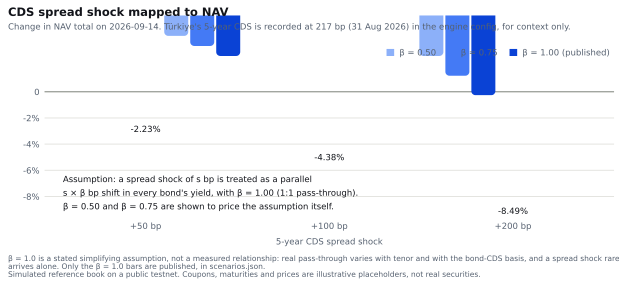

In [12]:
def draw_cds(fig, theme: Theme) -> None:
    ax = fig.add_axes((0.072, 0.245, 0.92, 0.50))
    shocks = [float(s) for s in config.scenarios.cds.shocks_bp]
    ax.set_xlim(-0.55, len(shocks) - 0.45)
    ax.set_ylim(-9.6, 1.4)
    ax.set_xticks(range(len(shocks)))
    ax.set_xticklabels([f"+{int(s)} bp" for s in shocks])
    ax.set_yticks([0, -2, -4, -6, -8])
    style_axes(ax, theme, x_rule=False)
    ax.yaxis.set_major_formatter(FuncFormatter(lambda v, _pos: f"{v:.0f}%" if v else "0"))
    ax.set_xlabel("5-year CDS spread shock", color=theme.muted, fontsize=8.5, labelpad=7)

    step = BAR_MAX_PX + GAP_PX
    for slot, beta in enumerate(BETAS):
        for index, result in enumerate(cds_grid[beta]):
            column(
                ax, index, 0, result.delta_pct, theme.ramp[slot],
                width_px=BAR_MAX_PX, offset_px=(slot - 1) * step,
            )
            if beta == published_beta:  # only the published column carries a direct label
                ax.text(
                    index, result.delta_pct - 0.35, f"{result.delta_pct:+.2f}%",
                    ha="center", va="top", color=theme.ink, fontsize=8.5,
                    transform=ax.transData,
                )
    ax.axhline(0, color=theme.axis, linewidth=1.0, zorder=2)

    # The assumption, on the figure rather than in a config file.
    ax.text(
        -0.45, -6.2,
        "Assumption: a spread shock of s bp is treated as a parallel\n"
        "s × β bp shift in every bond's yield, with β = 1.00 (1:1 pass-through).\n"
        "β = 0.50 and β = 0.75 are shown to price the assumption itself.",
        ha="left", va="top", color=theme.ink, fontsize=8.5, linespacing=1.6,
    )
    legend(
        ax, theme,
        [swatch(theme.ramp[slot], f"β = {beta:.2f}" + (" (published)" if beta == published_beta else "")) for slot, beta in enumerate(BETAS)],
        loc="upper right", bbox=(1.0, 1.20), ncol=3,
    )


render(
    "cds-shock",
    draw_cds,
    size=(8.6, 4.0),
    title="CDS spread shock mapped to NAV",
    subtitle=f"Change in NAV total on {AS_OF}. Türkiye's 5-year CDS is recorded at {reference_cds_bp:g} bp (31 Aug 2026) in the engine config, for context only.",
    notes=[
        "β = 1.0 is a stated simplifying assumption, not a measured relationship: real pass-through varies with tenor and with the bond-CDS basis, and a spread shock rarely arrives alone. Only the β = 1.0 bars are published, in scenarios.json.",
        SIM_NOTE,
    ],
)

## 5. Fee drag

The simulated schedule is a 0.75% management fee plus 0.30% of fund expenses, accruing every calendar day
after inception on the previous day's NAV total, on ACT/365F. `nav_engine.fees.daily_fee_accrual` is the
whole model: `NAV(d−1) × (0.75% + 0.30%) / 365`. Fees are a liability that reduces NAV — this engine
never pays them out — so on the as-of date the book carries 174.96 USD of accrued, unpaid fees after six
days.

Two things fall out of the arithmetic that are worth stating explicitly.

**The drag is 1.0445% a year, not 1.0500%.** Because each day's fee is charged on a NAV the previous
days' fees have already reduced, a 105 bp annual rate compounds *down* to 104.45 bp of unit NAV over 365
days. Small, but it is the difference between a fee schedule and a fee outcome, and a holder comparing
two funds should be comparing the second number.

**The drag does not improve with size.** A percentage-of-assets fee is scale-invariant by construction:
the same 1.0445% of NAV disappears at 10M and at 100M, only the dollars change — 104,452 USD against
1,044,522 USD. What scale actually buys is on the other side of the ledger: the fixed costs of a licensed
issuance (fund administration, custody, audit, legal) are roughly flat in dollars, so they consume a far
smaller share of a 100M fund. That effect is not modelled here, because inventing an operating-cost
curve for a fund that does not exist would be exactly the kind of made-up number this repository refuses
to publish.

Against the book's 6.42% gross yield to maturity, 105 bp of fees is about 16% of the gross yield. That is
the number a distribution partner will do in their head, so it may as well be on the page.

In [13]:
AUM_LEVELS = [Decimal(10_000_000), Decimal(50_000_000), Decimal(100_000_000)]
FEE_YEAR_DAYS = 365


def fee_path(start_nav: Decimal, days: int = FEE_YEAR_DAYS) -> list[Decimal]:
    # The engine's own daily accrual, iterated. NAV(d) = NAV(d-1) - fee(NAV(d-1)), which is exactly
    # what compute_nav_path does to the reference book, with the bonds held flat.
    nav, series = start_nav, [start_nav]
    for _ in range(days):
        nav -= daily_fee_accrual(
            nav,
            config.fund.management_fee_pct_pa,
            config.fund.fund_expenses_pct_pa,
            config.fund.fee_day_count_basis,
        )
        series.append(nav)
    return series


daily_rate = daily_fee_rate(
    config.fund.management_fee_pct_pa,
    config.fund.fund_expenses_pct_pa,
    config.fund.fee_day_count_basis,
)
unit_fee_path = fee_path(Decimal(1))
annual_drag_pct = float((Decimal(1) - unit_fee_path[-1]) * 100)

fees = pd.DataFrame(
    [
        {
            "AUM USD": f"{aum:,.0f}",
            "fee per day USD": usd(
                daily_fee_accrual(
                    aum,
                    config.fund.management_fee_pct_pa,
                    config.fund.fund_expenses_pct_pa,
                    config.fund.fee_day_count_basis,
                )
            ),
            "fee over 365 days USD": usd(aum - fee_path(aum)[-1]),
            "drag on unit NAV %": f"{annual_drag_pct:.4f}",
            "share of 6.42% gross YTM": f"{float(FUND_FEE_PCT) / day.weighted_ytm_pct * 100:.1f}%",
        }
        for aum in AUM_LEVELS
    ]
)
print(f"Schedule: {float(config.fund.management_fee_pct_pa):.2f}% management + {float(config.fund.fund_expenses_pct_pa):.2f}% fund expenses = {float(FUND_FEE_PCT):.2f}% a year, ACT/365F on the previous day's NAV total.")
print(f"Daily rate {float(daily_rate) * 1e6:.4f} bp of NAV; compounded over 365 days the drag is {annual_drag_pct:.4f}% of unit NAV, not {float(FUND_FEE_PCT):.4f}%.")
print(f"Accrued and unpaid on {AS_OF}, after {(AS_OF - path.inception_date).days} days on the simulated book: {usd(day.fees_payable)} USD.")
print("Simulated fee schedule for a testnet demonstration. Not a quoted fee for any product.")
fees.set_index("AUM USD")

Schedule: 0.75% management + 0.30% fund expenses = 1.05% a year, ACT/365F on the previous day's NAV total.
Daily rate 28.7671 bp of NAV; compounded over 365 days the drag is 1.0445% of unit NAV, not 1.0500%.
Accrued and unpaid on 2026-09-14, after 6 days on the simulated book: 174.96 USD.
Simulated fee schedule for a testnet demonstration. Not a quoted fee for any product.


,fee per day USD,fee over 365 days USD,drag on unit NAV %,share of 6.42% gross YTM
AUM USD,,,,
"10,000,000",287.67,"104,452.17",1.0445,16.4%
"50,000,000","1,438.36","522,260.84",1.0445,16.4%
"100,000,000","2,876.71","1,044,521.69",1.0445,16.4%


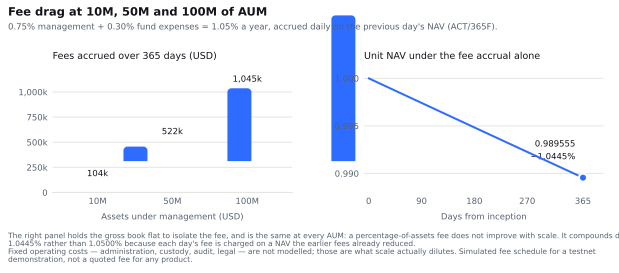

In [14]:
def draw_fees(fig, theme: Theme) -> None:
    grid = fig.add_gridspec(1, 2, left=0.085, right=0.975, top=0.755, bottom=0.295, wspace=0.30)
    ax_cost, ax_drag = fig.add_subplot(grid[0]), fig.add_subplot(grid[1])

    annual = [float(aum - fee_path(aum)[-1]) for aum in AUM_LEVELS]
    ax_cost.set_xlim(-0.6, len(AUM_LEVELS) - 0.4)
    ax_cost.set_ylim(0, 1_250_000)
    ax_cost.set_xticks(range(len(AUM_LEVELS)))
    ax_cost.set_xticklabels([f"{float(aum) / 1e6:,.0f}M" for aum in AUM_LEVELS])
    ax_cost.set_yticks([0, 250_000, 500_000, 750_000, 1_000_000])
    style_axes(ax_cost, theme)
    money_axis(ax_cost, theme, unit_divisor=1000.0, suffix="k")
    ax_cost.set_xlabel("Assets under management (USD)", color=theme.muted, fontsize=8.5, labelpad=7)
    width = bar_width_px(ax_cost, len(AUM_LEVELS))
    for index, value in enumerate(annual):
        column(ax_cost, index, 0, value, theme.accent, width_px=width)
        ax_cost.text(index, value + 38_000, f"{value / 1000:,.0f}k", ha="center", va="bottom", color=theme.ink, fontsize=8.5)
    axis_title(ax_cost, theme, "Fees accrued over 365 days (USD)")

    days = list(range(len(unit_fee_path)))
    ax_drag.set_xlim(-8, 400)
    ax_drag.set_ylim(0.9880, 1.0012)
    ax_drag.set_xticks([0, 90, 180, 270, 365])
    ax_drag.set_yticks([0.990, 0.995, 1.000])
    style_axes(ax_drag, theme, x_rule=False)
    ax_drag.yaxis.set_major_formatter(FuncFormatter(lambda v, _pos: f"{v:.3f}"))
    ax_drag.set_xlabel("Days from inception", color=theme.muted, fontsize=8.5, labelpad=7)
    ax_drag.plot([float(v) for v in unit_fee_path], color=theme.accent, linewidth=2.0, solid_capstyle="round", zorder=4)
    ax_drag.plot(
        [days[-1]], [float(unit_fee_path[-1])],
        marker="o", markersize=8, color=theme.accent,
        markeredgecolor=theme.surface, markeredgewidth=2.0, zorder=5,  # the 2 px surface ring
    )
    ax_drag.text(
        days[-1] - 13, float(unit_fee_path[-1]) + 0.0016,
        f"{unit(unit_fee_path[-1])}\n−{annual_drag_pct:.4f}%",
        ha="right", va="bottom", color=theme.ink, fontsize=8.5, linespacing=1.5,
    )
    axis_title(ax_drag, theme, "Unit NAV under the fee accrual alone")


render(
    "fee-drag",
    draw_fees,
    size=(8.6, 3.8),
    title="Fee drag at 10M, 50M and 100M of AUM",
    subtitle=f"{float(config.fund.management_fee_pct_pa):.2f}% management + {float(config.fund.fund_expenses_pct_pa):.2f}% fund expenses = {float(FUND_FEE_PCT):.2f}% a year, accrued daily on the previous day's NAV (ACT/365F).",
    notes=[
        "The right panel holds the gross book flat to isolate the fee, and is the same at every AUM: a percentage-of-assets fee does not improve with scale. It compounds down to " + f"{annual_drag_pct:.4f}% rather than {float(FUND_FEE_PCT):.4f}% because each day's fee is charged on a NAV the earlier fees already reduced.",
        "Fixed operating costs — administration, custody, audit, legal — are not modelled; those are what scale actually dilutes. Simulated fee schedule for a testnet demonstration, not a quoted fee for any product.",
    ],
)

## 6. Distribution yield, against a tokenized T-bill reference

The engine publishes a **trailing distribution yield**: distributions per token actually paid over the
trailing window, divided by the average unit NAV over the same window, annualised only once the window
reaches 30 days. On this as-of date it is 0.0000% over a 7-day window, and the annualised figure is
withheld with a note saying why. That is the correct answer and a useless chart: the fund was seeded six
days ago and has distributed nothing yet. Publishing an annualised yield from a 7-day window would be
the single most misleading number this repository could produce, which is why the engine refuses to.

So the comparison below is drawn on the measures that *are* defined today, each labelled for what it is:

- **Yield to maturity, gross** — 6.42%, the market-value weighted YTM from section 2. A held-to-maturity
  return before any fee, assuming the issuer pays.
- **Indicative coupon yield** — annual contractual coupon cash (64,680 USD) over NAV total. What the
  calendar in section 1 delivers as cash in a full year, as a share of today's NAV. It is not the same
  thing as YTM: it ignores the pull to par of a bond bought away from 100.
- **Yield to maturity, net of fees** — gross YTM minus the 105 bp schedule. A first-order net figure; the
  exact drag compounds to 1.0445% as section 5 showed.
- **Tokenized US T-bill reference** — 4.00%, an **illustrative placeholder** parameterised in
  `config.yaml` and labelled `illustrative: true` in `nav.json`. It is not a quote, not a specific
  product, and not sourced. It exists so the shape of the comparison is visible; the founders replace it
  with a cited public yield before this is shown to anyone outside the repository.

The gap between the two ends — roughly 137 bp net of fees — is the entire commercial argument for the
product, and it is the compensation for taking Türkiye sovereign credit risk, emerging-market duration
and a materially less liquid instrument instead of a T-bill. A reviewer should read that gap as a risk
premium to be underwritten, not as a free yield pick-up.

In [15]:
annual_coupon_cash = sum(
    (v.bond.coupon_per_period * v.bond.frequency for v in positions), Decimal(0)
)
tbill = config.comparison.tokenized_tbill_reference

yield_measures = [
    ("Yield to maturity, gross", day.weighted_ytm_pct, "fund"),
    ("Indicative coupon yield (annual coupon ÷ NAV)", float(annual_coupon_cash / day.nav_total) * 100, "fund"),
    ("Yield to maturity, net of the 1.05% fee schedule", day.weighted_ytm_pct - float(FUND_FEE_PCT), "fund"),
    (tbill.label, tbill.yield_pct, "reference"),
]

yields = pd.DataFrame(
    [
        {
            "measure": label,
            "% a year": f"{value:.4f}",
            "what it is": {
                "fund": "computed from the simulated book",
                "reference": "illustrative placeholder, not sourced",
            }[kind],
        }
        for label, value, kind in yield_measures
    ]
)

trailing = documents.nav.distribution_yield
print("Engine-published trailing distribution yield (nav.json):")
print(f"  distributions per token in window  {unit(trailing.trailing_per_unit_usd)} USD")
print(f"  window                             {trailing.window_days} days ({trailing.months_available} of {config.distribution_yield.trailing_months} months available)")
print(f"  average unit NAV in window         {unit(trailing.average_nav_per_unit)} USD")
print(f"  raw trailing yield                 {trailing.raw_pct:.4f}%")
print(f"  annualised                         {trailing.annualized_pct if trailing.annualized_pct is not None else 'withheld'}")
print(f"  note                               {trailing.note}")
print()
print(f"Annual contractual coupon cash: {usd(annual_coupon_cash)} USD on a NAV total of {usd(day.nav_total)} USD.")
print(f"{tbill.label}: {tbill.yield_pct:.2f}% — {tbill.source_note}")
yields.set_index("measure")

Engine-published trailing distribution yield (nav.json):
  distributions per token in window  0.000000 USD
  window                             7 days (0 of 12 months available)
  average unit NAV in window         1.000352 USD
  raw trailing yield                 0.0000%
  annualised                         withheld
  note                               Only 7 day(s) since inception; the annualised yield is withheld until the window reaches 30 days. Raw trailing yield shown. Simulated distributions (testnet).

Annual contractual coupon cash: 64,680.00 USD on a NAV total of 1,016,860.71 USD.
Tokenized US T-bill reference (illustrative): 4.00% — Illustrative placeholder. Replace with a cited public yield before any external use.


,% a year,what it is
measure,,
"Yield to maturity, gross",6.4210,computed from the simulated book
Indicative coupon yield (annual coupon ÷ NAV),6.3608,computed from the simulated book
"Yield to maturity, net of the 1.05% fee schedule",5.3710,computed from the simulated book
Tokenized US T-bill reference (illustrative),4.0000,"illustrative placeholder, not sourced"


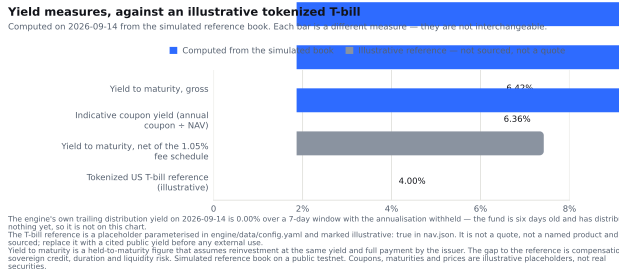

In [16]:
def draw_yields(fig, theme: Theme) -> None:
    ax = fig.add_axes((0.345, 0.285, 0.575, 0.465))
    labels = [label for label, _value, _kind in yield_measures]
    values = [value for _label, value, _kind in yield_measures]
    ax.set_ylim(-0.6, len(values) - 0.4)
    ax.set_xlim(0, 8.0)
    ax.invert_yaxis()
    ax.set_yticks(range(len(values)))
    ax.set_yticklabels(["\n".join(_wrap(fig, label, 210, 8.5)) for label in labels])
    ax.set_xticks([0, 2, 4, 6, 8])
    style_axes(ax, theme, grid_axis="x")
    ax.xaxis.set_major_formatter(FuncFormatter(lambda v, _pos: f"{v:.0f}%" if v else "0"))
    height = min(BAR_MAX_PX, 0.62 * abs(ax.transData.transform((0, 0))[1] - ax.transData.transform((0, 1))[1]))
    for index, (_label, value, kind) in enumerate(yield_measures):
        # The fund's own measures share one colour; the external reference wears the neutral that
        # chart-theme.css reserves for "not a bond".
        hbar(ax, index, 0, value, theme.accent if kind == "fund" else theme.neutral, height_px=height)
        ax.text(value + 0.16, index, f"{value:.2f}%", ha="left", va="center", color=theme.ink, fontsize=8.5)
    legend(
        ax, theme,
        [
            swatch(theme.accent, "Computed from the simulated book"),
            swatch(theme.neutral, "Illustrative reference — not sourced, not a quote"),
        ],
        loc="upper right", bbox=(1.0, 1.21), ncol=2,
    )


render(
    "distribution-yield",
    draw_yields,
    size=(8.6, 3.9),
    title="Yield measures, against an illustrative tokenized T-bill",
    subtitle=f"Computed on {AS_OF} from the simulated reference book. Each bar is a different measure — they are not interchangeable.",
    notes=[
        f"The engine's own trailing distribution yield on {AS_OF} is {trailing.raw_pct:.2f}% over a {trailing.window_days}-day window with the annualisation withheld — the fund is six days old and has distributed nothing yet, so it is not on this chart.",
        "The T-bill reference is a placeholder parameterised in engine/data/config.yaml and marked illustrative: true in nav.json. It is not a quote, not a named product and not sourced; replace it with a cited public yield before any external use.",
        "Yield to maturity is a held-to-maturity figure that assumes reinvestment at the same yield and full payment by the issuer. The gap to the reference is compensation for sovereign credit, duration and liquidity risk. " + SIM_NOTE,
    ],
)

## What this notebook does not model

An analysis is only trustworthy if it says where it stops. This one stops here:

- **The book is simulated.** Three illustrative bonds, `TBD` ISINs, invented clean prices, a 12,500 USD
  cash balance and test USDC. The coupon and maturity structure was chosen to sit on the Türkiye USD
  curve as observed on 31 August 2026; it is not a portfolio anyone holds.
- **No credit model.** Yield to maturity assumes the issuer pays in full and on time. A sovereign default,
  a restructuring or a missed coupon is not in any number above. The CDS section prices a *spread* move,
  which is the market's changing opinion about that risk — not the event.
- **The CDS mapping is a stated assumption, not a measurement.** β = 1.0, flat across tenors. Section 4
  shows what the answer would be at 0.5 and 0.75 precisely so the size of that assumption is visible.
- **Parallel shifts only.** Real curves steepen and twist; a 2029 and a 2036 rarely move by the same
  amount. Key-rate durations would answer that, and are not computed here.
- **No liquidity model.** Redemption is assumed to happen at NAV. In practice a forced seller of an
  emerging-market sovereign bond pays a bid-offer spread that widens exactly when they most need to sell,
  and the fund's on-chain redemption is limited by the vault's USDC balance — `RISKS.md` and
  `SECURITY.md` cover that, this notebook does not.
- **No operating-cost curve.** Section 5 models the stated percentage fee and nothing else. Fund
  administration, custody, audit and legal costs are real and roughly fixed in dollars; they are not
  invented here.
- **No reinvestment rule.** The cash-flow calendar is buy-and-hold: coupons and the 2029 principal land in
  cash and stay there. A real fund reinvests, and where it reinvests changes duration and yield.
- **The T-bill reference is a placeholder.** 4.00%, unsourced, labelled `illustrative` everywhere it
  appears. Replace it with a cited public yield before this comparison is shown to anyone.

Everything above is computed by `nav_engine` and tied out against the published documents in the second
cell; everything listed here is absent. Both lists matter.

In [17]:
manifest = pd.DataFrame(
    [
        {
            "figure": name,
            "light": f"docs/figures/{name}-light.svg",
            "dark": f"docs/figures/{name}-dark.svg",
        }
        for name in FIGURES
    ]
)
missing = [
    target
    for name in FIGURES
    for target in (FIG_DIR / f"{name}-light.svg", FIG_DIR / f"{name}-dark.svg")
    if not target.is_file()
]
assert not missing, f"figures were not written: {missing}"

print(f"{len(FIGURES)} figures, {2 * len(FIGURES)} files, under {FIG_DIR.relative_to(ROOT)}/")
print(f"Valuation date {AS_OF}, stamped {GENERATED_AT}; every figure and table above ties to web/public/data.")
print("No wall-clock input anywhere: re-running this notebook produces identical output.")
manifest.set_index("figure")

6 figures, 12 files, under docs/figures/
Valuation date 2026-09-14, stamped 2026-09-14T06:00:00Z; every figure and table above ties to web/public/data.
No wall-clock input anywhere: re-running this notebook produces identical output.


,light,dark
figure,,
cashflow-calendar,docs/figures/cashflow-calendar-light.svg,docs/figures/cashflow-calendar-dark.svg
risk-by-bond,docs/figures/risk-by-bond-light.svg,docs/figures/risk-by-bond-dark.svg
nav-sensitivity,docs/figures/nav-sensitivity-light.svg,docs/figures/nav-sensitivity-dark.svg
cds-shock,docs/figures/cds-shock-light.svg,docs/figures/cds-shock-dark.svg
fee-drag,docs/figures/fee-drag-light.svg,docs/figures/fee-drag-dark.svg
distribution-yield,docs/figures/distribution-yield-light.svg,docs/figures/distribution-yield-dark.svg


---

*Testnet demonstration on Base Sepolia. Simulated portfolio and attestation. Not an offer of securities.
Portfolio data, prices and attestations are simulated or illustrative and are labelled as such. Nothing
here is an offer, solicitation or recommendation to buy any security. HitBite is not a licensed financial
institution.*